**Perbandingan Model Deep Learning Berbasis Data Sequence untuk Tugas Regresi dalam Prediksi Suhu Harian Menggunakan Data Cuaca Indonesia**

In [1]:
# ===============================
# 1. IMPORT LIBRARY
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import tensorflow as tf
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)


2026-04-19 05:26:09.059797: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776576369.244013      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776576369.300479      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776576369.760884      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776576369.760932      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776576369.760934      55 computation_placer.cc:177] computation placer alr

Pada bagian ini, kode mengimpor berbagai library yang dibutuhkan untuk keseluruhan proses. Library seperti numpy dan pandas digunakan untuk manipulasi data, sedangkan matplotlib digunakan untuk visualisasi. Kemudian, dari sklearn digunakan MinMaxScaler untuk normalisasi data serta metrik evaluasi seperti MAE dan RMSE. Untuk pemodelan, digunakan tensorflow.keras yang menyediakan berbagai arsitektur deep learning seperti RNN, LSTM, GRU, serta layer tambahan seperti Dropout. Callback seperti EarlyStopping dan ReduceLROnPlateau juga disiapkan untuk mengoptimalkan proses training agar tidak overfitting dan lebih stabil.

In [2]:
# ===============================
# 2. LOAD DATA
# ===============================
df = pd.read_csv('/kaggle/input/datasets/shivamshinde1904/weather-data2000-2023/Indonesia_weather_data.csv')


Pada tahap ini, dataset cuaca Indonesia dibaca menggunakan pandas.read_csv. Dataset ini berisi data time series seperti suhu, curah hujan, dan kecepatan angin dari tahun 2000 hingga 2023. Data ini menjadi dasar utama dalam membangun model prediksi suhu.

In [3]:
# ===============================
# 3. PREPROCESSING
# ===============================
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.sort_values('Date')

# handle missing (FIXED)
df = df.ffill().bfill()

Data pada kolom tanggal diubah menjadi format datetime agar bisa diproses sebagai time series, kemudian data diurutkan berdasarkan waktu. Missing values ditangani menggunakan metode forward fill dan backward fill, sehingga tidak ada nilai kosong yang dapat mengganggu training model. Hasil dari tahap ini adalah data yang sudah bersih dan terurut secara kronologis.

In [4]:
# ===============================
# 4. HANDLE OUTLIER (IQR CLIPPING)
# ===============================
q1 = df['Temp_Mean'].quantile(0.25)
q3 = df['Temp_Mean'].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df['Temp_Mean'] = df['Temp_Mean'].clip(lower, upper)

Pada bagian ini dilakukan penanganan outlier menggunakan metode IQR. Nilai suhu yang terlalu ekstrem (di luar batas bawah dan atas) akan dipotong (clipping) agar tidak mempengaruhi model secara berlebihan. Hasilnya adalah distribusi data yang lebih stabil dan tidak bias akibat nilai ekstrem.

In [5]:
# ===============================
# 5. SMOOTHING (REDUCE NOISE)
# ===============================
df['Temp_Smooth'] = df['Temp_Mean'].rolling(3).mean()

Data suhu kemudian dihaluskan menggunakan rolling mean (rata-rata bergerak) dengan window 3 hari. Tujuannya adalah mengurangi noise atau fluktuasi acak pada data. Hasilnya adalah fitur baru Temp_Smooth yang lebih stabil dibandingkan suhu asli, sehingga lebih mudah dipelajari oleh model.

In [6]:
# ===============================
# 6. FEATURE ENGINEERING
# ===============================
df['month'] = df['Date'].dt.month

df['temp_roll_mean_7'] = df['Temp_Mean'].rolling(7).mean()

df = df.dropna()

Pada tahap ini ditambahkan fitur baru seperti bulan (month) untuk menangkap pola musiman, serta rolling mean 7 hari (temp_roll_mean_7) untuk menangkap tren jangka pendek. Setelah itu, baris yang mengandung nilai NaN akibat rolling dihapus. Hasilnya adalah dataset dengan fitur yang lebih kaya dan informatif.

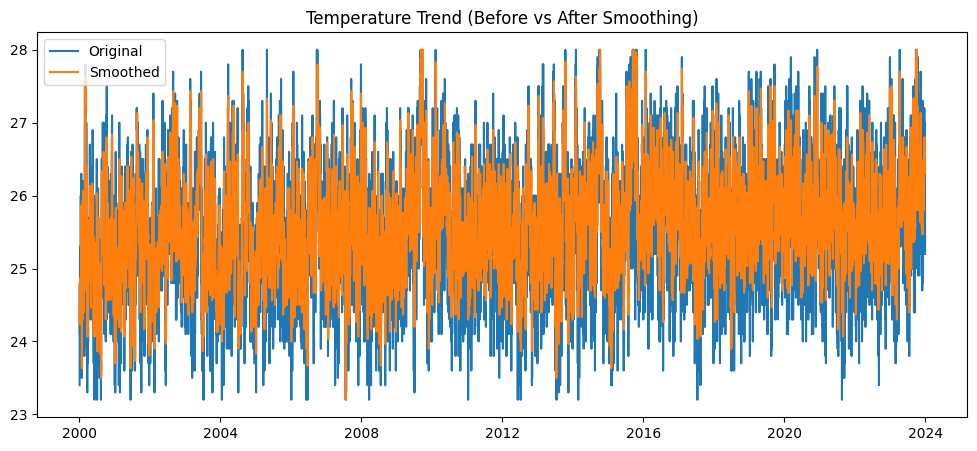

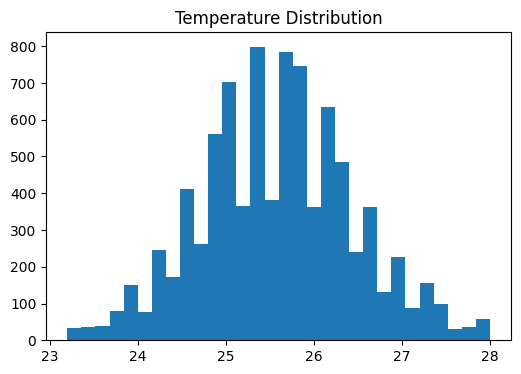

In [7]:
# ===============================
# 7. VISUAL EDA
# ===============================
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Temp_Mean'], label='Original')
plt.plot(df['Date'], df['Temp_Smooth'], label='Smoothed')
plt.legend()
plt.title("Temperature Trend (Before vs After Smoothing)")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df['Temp_Mean'], bins=30)
plt.title("Temperature Distribution")
plt.show()

Visualisasi dilakukan untuk memahami pola data. Grafik pertama menunjukkan perbandingan antara suhu asli dan hasil smoothing, yang memperlihatkan bahwa data menjadi lebih halus. Histogram menunjukkan distribusi suhu, sehingga bisa dilihat apakah data normal atau tidak. Hasil visual ini membantu memastikan bahwa preprocessing berjalan dengan baik.

In [8]:
# ===============================
# 8. FEATURES
# ===============================
features = [
    'Temp_Smooth',   
    'Temp_Max',
    'Temp_Min',
    'Precipitation_Sum',
    'Windspeed_Max',
    'temp_roll_mean_7',
    'month'
]

data = df[features].values

Pada bagian ini dipilih fitur-fitur yang akan digunakan dalam model. Temp_Smooth dijadikan target utama karena lebih stabil, sementara fitur lain seperti suhu maksimum, minimum, curah hujan, dan angin digunakan sebagai input. Hasilnya adalah matriks data numerik yang siap diproses model.

In [9]:
# ===============================
# 9. SCALING
# ===============================
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


Data dinormalisasi menggunakan MinMaxScaler ke rentang 0–1. Hal ini penting karena model deep learning sangat sensitif terhadap skala data. Hasilnya adalah data yang memiliki distribusi seragam sehingga training menjadi lebih cepat dan stabil.

In [10]:
# ===============================
# 10. CREATE SEQUENCE
# ===============================
def create_dataset(data, window_size=14):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size][0])
    return np.array(X), np.array(y)

window_size = 14
X, y = create_dataset(data_scaled, window_size)

Data time series diubah menjadi format sequence menggunakan window size 14 hari. Artinya, model akan menggunakan 14 hari sebelumnya untuk memprediksi hari berikutnya. Hasilnya adalah dataset berbentuk 3D (samples, timesteps, features) yang sesuai untuk model RNN.

In [11]:
# ===============================
# 11. SPLIT DATA
# ===============================
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


Data dibagi menjadi training (80%) dan testing (20%). Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk evaluasi. Pembagian ini penting agar performa model bisa diuji secara objektif.

In [12]:
# ===============================
# 12. INVERSE FUNCTION
# ===============================
def inverse_transform(y_scaled):
    temp = np.zeros((len(y_scaled), data.shape[1]))
    temp[:,0] = y_scaled.flatten()
    return scaler.inverse_transform(temp)[:,0]


Fungsi ini digunakan untuk mengembalikan hasil prediksi dari skala 0–1 ke nilai suhu asli. Karena scaler bekerja pada banyak fitur, dibuat array dummy agar hanya kolom target yang dikembalikan. Hasilnya adalah prediksi dalam satuan derajat Celsius yang bisa diinterpretasikan.

In [13]:
# ===============================
# 13. CALLBACKS
# ===============================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)


EarlyStopping digunakan untuk menghentikan training jika tidak ada peningkatan pada validation loss, sedangkan ReduceLROnPlateau menurunkan learning rate jika model stagnan. Hasilnya adalah training yang lebih efisien dan menghindari overfitting.

In [14]:
# ===============================
# 14. EVALUATION FUNCTION
# ===============================
results = []

def evaluate_model(model, name, history):
    y_pred = model.predict(X_test)

    y_pred_inv = inverse_transform(y_pred)
    y_true_inv = inverse_transform(y_test.reshape(-1,1))

    mae = mean_absolute_error(y_true_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))

    print(f"{name} -> MAE: {mae:.3f}, RMSE: {rmse:.3f}")

    results.append({"Model": name, "MAE": mae, "RMSE": rmse})

    plt.figure(figsize=(10,4))
    plt.plot(y_true_inv[:100], label='Actual')
    plt.plot(y_pred_inv[:100], label='Predicted')
    plt.title(name)
    plt.legend()
    plt.show()

Fungsi ini menghitung MAE dan RMSE untuk mengevaluasi performa model. Selain itu, ditampilkan grafik perbandingan antara nilai aktual dan prediksi. Hasil dari bagian ini adalah ukuran akurasi model dan visualisasi performanya.

2026-04-19 05:26:29.795011: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training RNN...
Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1045 - val_loss: 0.0166 - learning_rate: 0.0010
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0125 - val_loss: 0.0109 - learning_rate: 0.0010
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0079 - val_loss: 0.0057 - learning_rate: 0.0010
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0058 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0055 - val_loss: 0.0040 - learning_rate: 0.0010
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0050 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0046 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0043 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 9/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0040 - val_loss: 0.0032 - learning_rate: 

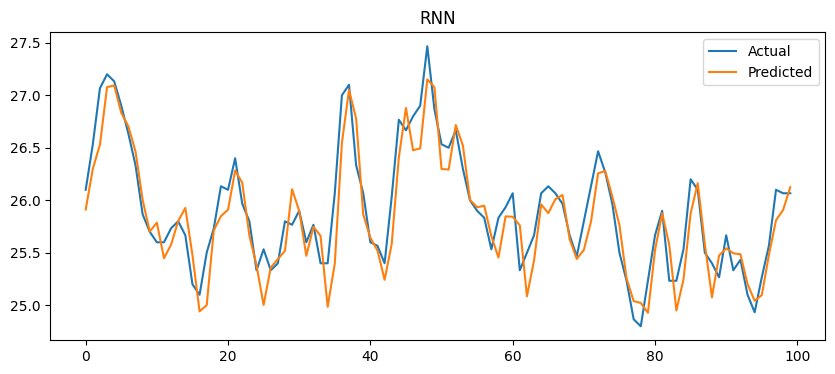


Training LSTM...
Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0258 - val_loss: 0.0125 - learning_rate: 0.0010
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0091 - val_loss: 0.0075 - learning_rate: 0.0010
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0056 - val_loss: 0.0062 - learning_rate: 0.0010
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0045 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0042 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0040 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0037 - val_loss: 0.0048 - learning_rate: 0.0010
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0036 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 9/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0034 - val_loss: 0.0043 - learn

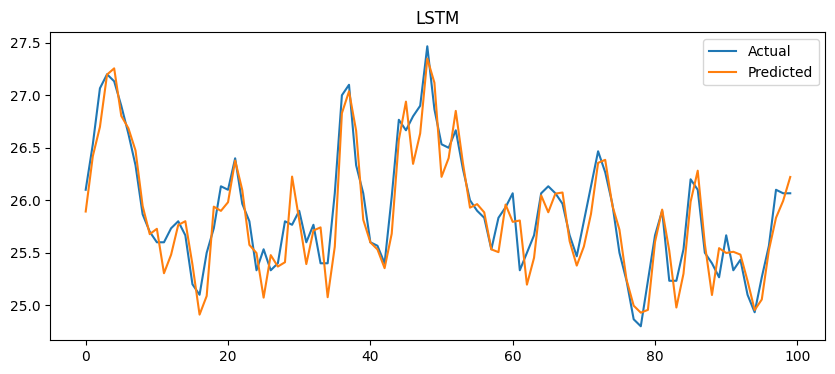


Training GRU...
Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0639 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0070 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0051 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0044 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0038 - val_loss: 0.0049 - learning_rate: 0.0010
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0036 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0034 - val_loss: 0.0039 - learning_rate: 0.0010
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0033 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 9/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0031 - val_loss: 0.0034 - learni

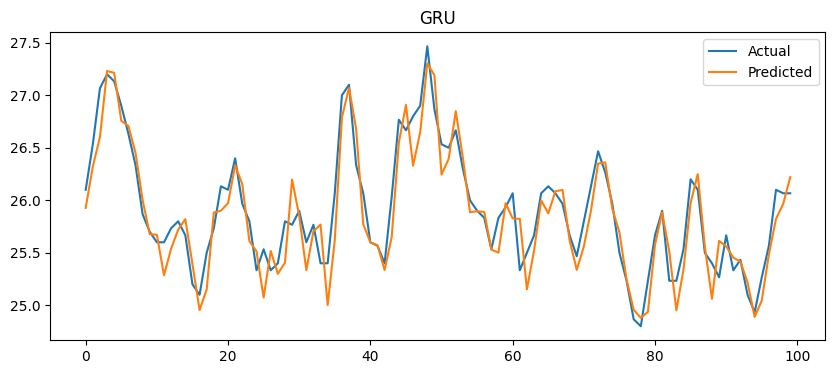


Training BiLSTM...
Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0320 - val_loss: 0.0124 - learning_rate: 0.0010
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0077 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0054 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0045 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0042 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0041 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0039 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0038 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 9/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0037 - val_loss: 0.0048 - lea

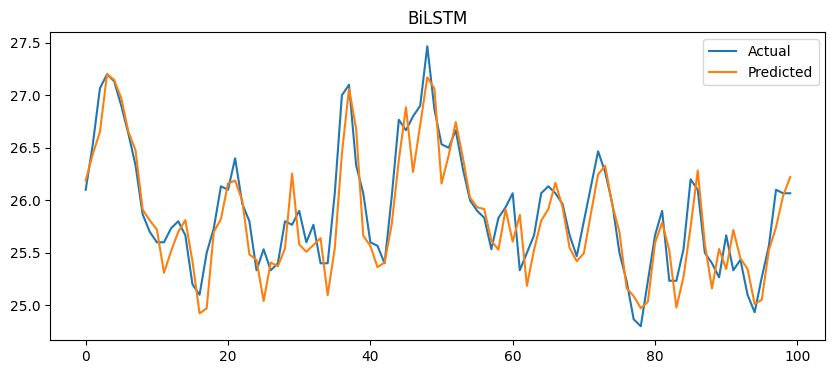


Training BiGRU...
Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0273 - val_loss: 0.0062 - learning_rate: 0.0010
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0052 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0046 - val_loss: 0.0047 - learning_rate: 0.0010
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0042 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0039 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0034 - val_loss: 0.0032 - learning_rate: 0.0010
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0032 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0031 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 9/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0030 - val_loss: 0.0031 - lear

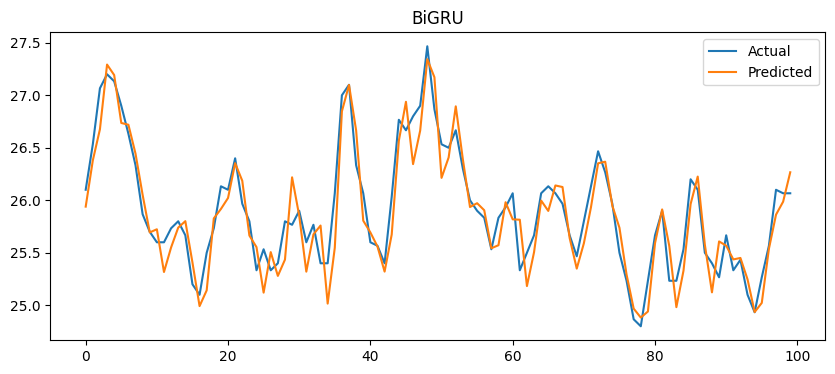

In [15]:
# ===============================
# 15. MODELS (5 WAJIB)
# ===============================

def build_rnn():
    model = Sequential([
        SimpleRNN(64, return_sequences=True, input_shape=(window_size, X.shape[2])),
        Dropout(0.2),
        SimpleRNN(32),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm():
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(window_size, X.shape[2])),
        Dropout(0.2),
        LSTM(32),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru():
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=(window_size, X.shape[2])),
        Dropout(0.2),
        GRU(32),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_bilstm():
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=(window_size, X.shape[2])),
        Dropout(0.2),
        Bidirectional(LSTM(32)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_bigru():
    model = Sequential([
        Bidirectional(GRU(64, return_sequences=True), input_shape=(window_size, X.shape[2])),
        Dropout(0.2),
        Bidirectional(GRU(32)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model


models = {
    "RNN": build_rnn(),
    "LSTM": build_lstm(),
    "GRU": build_gru(),
    "BiLSTM": build_bilstm(),
    "BiGRU": build_bigru()
}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    
    evaluate_model(model, name, history)


Dibangun lima model: RNN, LSTM, GRU, BiLSTM, dan BiGRU. Masing-masing model memiliki arsitektur yang mirip dengan dua layer utama dan dropout. Tujuannya adalah membandingkan performa berbagai arsitektur deep learning terhadap data yang sama.


=== MODEL COMPARISON ===
    Model       MAE      RMSE
4   BiGRU  0.201149  0.253602
2     GRU  0.206177  0.258927
1    LSTM  0.208646  0.262840
0     RNN  0.209976  0.263913
3  BiLSTM  0.230102  0.292123


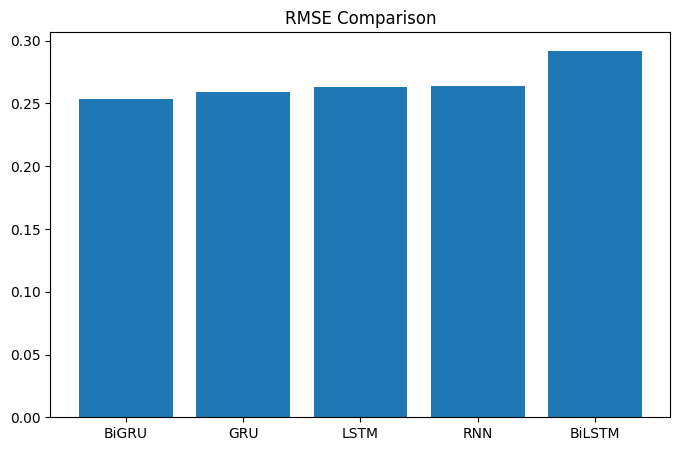

In [16]:
# ===============================
# 16. COMPARISON
# ===============================
results_df = pd.DataFrame(results).sort_values(by="RMSE")

print("\n=== MODEL COMPARISON ===")
print(results_df)

plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['RMSE'])
plt.title("RMSE Comparison")
plt.show()

Hasil evaluasi semua model dikumpulkan dalam DataFrame dan diurutkan berdasarkan RMSE. Kemudian divisualisasikan dalam bentuk bar chart. Hasil ini menunjukkan model mana yang memiliki performa terbaik.

In [17]:
# ===============================
# 17. PREDIKSI (BEST MODEL)
# ===============================
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

last_sequence = data_scaled[-window_size:]
last_sequence = last_sequence.reshape(1, window_size, X.shape[2])

pred_scaled = best_model.predict(last_sequence)
pred_actual = inverse_transform(pred_scaled)

print(f"\nBest Model: {best_model_name}")
print("Prediksi suhu berikutnya:", pred_actual[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

Best Model: BiGRU
Prediksi suhu berikutnya: 25.906919956207275


Model terbaik dipilih berdasarkan RMSE terendah. Kemudian digunakan untuk memprediksi suhu berikutnya berdasarkan sequence terakhir dari dataset. Hasilnya adalah satu nilai prediksi suhu di masa depan.

In [18]:
# ===============================
# 🔥 PREDIKSI SUHU (INPUT FIXED 5 HARI)
# ===============================

print("\n=== PREDIKSI SUHU (INPUT FIXED 5 HARI) ===")

# ambil model terbaik
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"Model yang digunakan: {best_model_name}")

# ===============================
# 🔹 INPUT SUHU (FIXED)
# ===============================
input_suhu = [22, 30, 25, 29, 31]

# ===============================
# 🔹 BENTUK DATA SESUAI MODEL
# ===============================

last_data = data[-1]  # ambil fitur terakhir dari dataset

input_full = []

for temp in input_suhu:
    row = last_data.copy()
    row[0] = temp  # ganti Temp_Smooth
    input_full.append(row)

input_full = np.array(input_full)

# ===============================
# 🔹 SCALING
# ===============================
input_scaled = scaler.transform(input_full)

# reshape jadi (1, 5, features)
input_scaled = input_scaled.reshape(1, 5, data.shape[1])

# ===============================
# 🔹 PREDIKSI
# ===============================
pred_scaled = best_model.predict(input_scaled)
pred_actual = inverse_transform(pred_scaled)

# ===============================
# 🔹 OUTPUT
# ===============================
print("\n📊 HASIL:")
print("Input 5 hari:", input_suhu)
print("Prediksi suhu hari berikutnya:", pred_actual[0])


=== PREDIKSI SUHU (INPUT FIXED 5 HARI) ===
Model yang digunakan: BiGRU
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step

📊 HASIL:
Input 5 hari: [22, 30, 25, 29, 31]
Prediksi suhu hari berikutnya: 31.098416328430172


Bagian ini memungkinkan prediksi berdasarkan input manual (5 hari terakhir). Data input disesuaikan dengan format fitur, kemudian di-scaling, diprediksi, dan di-inverse kembali ke suhu asli. Hasilnya adalah prediksi suhu hari ke-6 berdasarkan 5 hari sebelumnya.